# Chapter 5 - Exploratory Data Analysis

In the previous chapters, we learned how to gather and clean data. Now we move to Exploratory Data Analysis, usually called EDA.

EDA is the process of studying a dataset to understand its main patterns, unusual values, relationships, and useful features before building a Machine Learning model. 

In this chapter, we will use the Titanic dataset to practice EDA step by step.

## What is EDA?

Exploratory Data Analysis means asking questions about data and using summary
statistics and visualizations to answer them.

During EDA, we usually try to understand:

- what columns are present in the dataset
- which columns are numerical and which are categorical
- whether values are missing or duplicated
- how individual variables are distributed
- how variables are related to each other
- which features may be useful for modeling

## Why EDA is Important for Machine Learning

EDA helps us avoid blind modeling. Before training a model, we should know what
the data looks like and what problems it contains.

EDA helps us:

- understand data distributions
- identify patterns and relationships
- detect anomalies and outliers
- guide feature selection
- shape modeling strategies

## The Flow of EDA

EDA is flexible, but a useful flow is:

1. Load and inspect the dataset.
2. Separate numerical and categorical variables.
3. Perform univariate analysis on one variable at a time.
4. Perform bivariate analysis between two variables.
5. Perform multivariate analysis across multiple variables.
6. Use correlation analysis to study numerical relationships.

We will follow this flow on the Titanic dataset.

## Practical EDA on Titanic Dataset

The Titanic dataset contains passenger information such as age, sex, passenger
class, fare, cabin, port of embarkation, and survival status. This makes it a
useful dataset for learning EDA because it contains both numerical and
categorical features.

In [ ]:
# Common imports used throughout the code
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
    
DATA_PATH = "https://raw.githubusercontent.com/kanetkar/LULML/refs/heads/main/ch05/titanic.csv"

# Load the Titanic dataset
titanic_data = pd.read_csv(DATA_PATH)

In [43]:
print("First 5 rows of the Titanic dataset:")
print(titanic_data.head())

First 5 rows of the Titanic dataset:
   survived  pclass                                               name  \
0         0       3                            Braund, Mr. Owen Harris   
1         1       1  Cumings, Mrs. John Bradley (Florence Briggs Th...   
2         1       3                             Heikkinen, Miss. Laina   
3         1       1       Futrelle, Mrs. Jacques Heath (Lily May Peel)   
4         0       3                           Allen, Mr. William Henry   

      sex   age  sibsp  parch            ticket     fare cabin embarked  
0    male  22.0      1      0         A/5 21171   7.2500   NaN        S  
1  female  38.0      1      0          PC 17599  71.2833   C85        C  
2  female  26.0      0      0  STON/O2. 3101282   7.9250   NaN        S  
3  female  35.0      1      0            113803  53.1000  C123        S  
4    male  35.0      0      0            373450   8.0500   NaN        S  


In [44]:
print("\nDataset information:")
titanic_data.info()


Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   survived  891 non-null    int64  
 1   pclass    891 non-null    int64  
 2   name      891 non-null    str    
 3   sex       891 non-null    str    
 4   age       714 non-null    float64
 5   sibsp     891 non-null    int64  
 6   parch     891 non-null    int64  
 7   ticket    891 non-null    str    
 8   fare      891 non-null    float64
 9   cabin     204 non-null    str    
 10  embarked  889 non-null    str    
dtypes: float64(2), int64(4), str(5)
memory usage: 76.7 KB


The above inspection tells us the number of rows and columns, the column names,
and the data type of each column. 

It also shows that columns such as `age`, `cabin`, and `embarked` contain missing values.

In [45]:
print("Missing values in each column:")
print(titanic_data.isnull().sum())

Missing values in each column:
survived      0
pclass        0
name          0
sex           0
age         177
sibsp         0
parch         0
ticket        0
fare          0
cabin       687
embarked      2
dtype: int64


In [46]:
print("Number of duplicate rows:")
print(titanic_data.duplicated().sum())

Number of duplicate rows:
0


Checking missing values and duplicates gives us the basic health report of the
dataset before we start deeper analysis.

## Univariate Analysis

Univariate analysis studies one variable at a time. 

For numerical variables, we use summary statistics, histograms, KDE curves, and box plots. 

For categorical variables, we use counts and bar plots.

In [47]:
# Separate columns by data type so that we can analyze them correctly.
numerical_cols = titanic_data.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols = titanic_data.select_dtypes(include=["object", "string"]).columns.tolist()

print("Numerical Columns:", numerical_cols)
print("Categorical Columns:", categorical_cols)

Numerical Columns: ['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare']
Categorical Columns: ['name', 'sex', 'ticket', 'cabin', 'embarked']


This separation is important because numerical and categorical columns need
different types of summaries and graphs.

### Univariate Analysis on Age

We begin with `age`, a numerical column. First, we look at summary statistics.

In [48]:
print("Summary statistics for age:")
print(titanic_data["age"].describe())

Summary statistics for age:
count    714.000000
mean      29.699118
std       14.526497
min        0.420000
25%       20.125000
50%       28.000000
75%       38.000000
max       80.000000
Name: age, dtype: float64


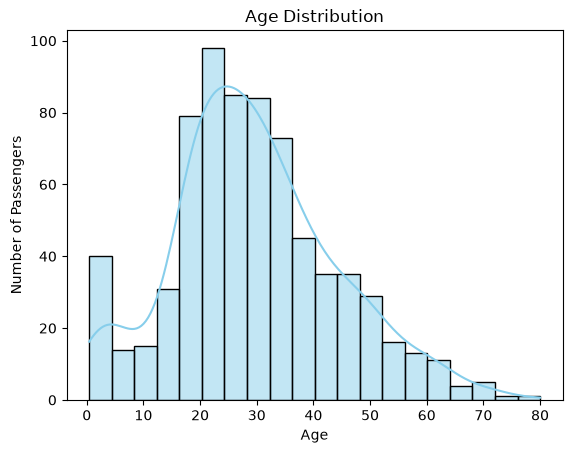

In [49]:
sns.histplot(titanic_data["age"], kde=True, bins=20, color="skyblue")
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Passengers")
plt.show()

In [50]:
print("Skewness of age:")
print(titanic_data["age"].skew())

Skewness of age:
0.38910778230082704


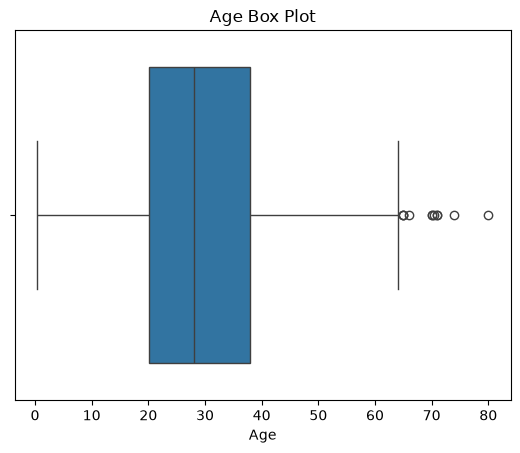

In [51]:
sns.boxplot(x=titanic_data["age"])
plt.title("Age Box Plot")
plt.xlabel("Age")
plt.show()

The age distribution shows many passengers in the young adult range. The box
plot helps us see the spread of ages and possible older-passenger outliers.

### Univariate Analysis on Fare

Next, we analyze `fare`, another numerical column.

In [52]:
print("Summary statistics for fare:")
print(titanic_data["fare"].describe())

Summary statistics for fare:
count    891.000000
mean      32.204208
std       49.693429
min        0.000000
25%        7.910400
50%       14.454200
75%       31.000000
max      512.329200
Name: fare, dtype: float64


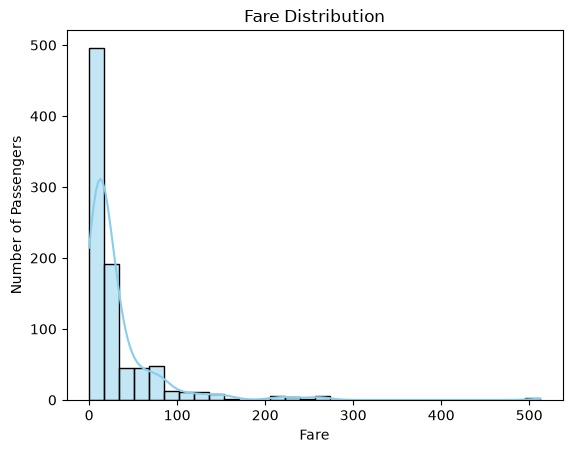

In [53]:
sns.histplot(titanic_data["fare"], kde=True, bins=30, color="skyblue")
plt.title("Fare Distribution")
plt.xlabel("Fare")
plt.ylabel("Number of Passengers")
plt.show()

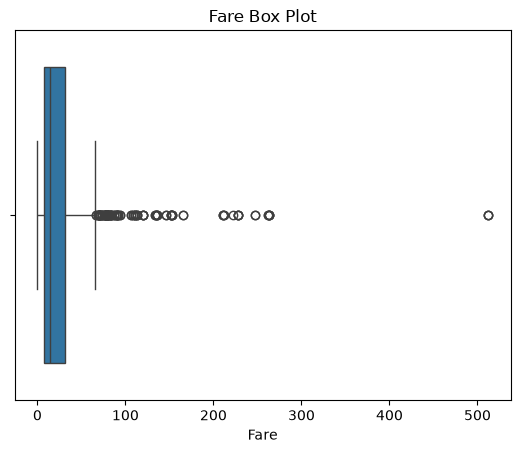

In [54]:
sns.boxplot(x=titanic_data["fare"])
plt.title("Fare Box Plot")
plt.xlabel("Fare")
plt.show()

In [55]:
high_fare_passengers = titanic_data[titanic_data["fare"] > 250]
print("Passengers with fare greater than 250:")
print(high_fare_passengers[["name", "ticket", "fare"]])

Passengers with fare greater than 250:
                                      name    ticket      fare
27          Fortune, Mr. Charles Alexander     19950  263.0000
88              Fortune, Miss. Mabel Helen     19950  263.0000
258                       Ward, Miss. Anna  PC 17755  512.3292
311             Ryerson, Miss. Emily Borie  PC 17608  262.3750
341         Fortune, Miss. Alice Elizabeth     19950  263.0000
438                      Fortune, Mr. Mark     19950  263.0000
679     Cardeza, Mr. Thomas Drake Martinez  PC 17755  512.3292
737                 Lesurer, Mr. Gustave J  PC 17755  512.3292
742  Ryerson, Miss. Susan Parker "Suzette"  PC 17608  262.3750


The fare column is strongly right-skewed. Some passengers paid very high fares,
often because the ticket represented a group or family booking.

### Creating IndividualFare

To understand fare more accurately, we calculate group size from the ticket
number and divide total fare by group size.

In [56]:
print("Before creating IndividualFare:")
print(titanic_data[["ticket", "fare"]].head())

Before creating IndividualFare:
             ticket     fare
0         A/5 21171   7.2500
1          PC 17599  71.2833
2  STON/O2. 3101282   7.9250
3            113803  53.1000
4            373450   8.0500


In [57]:
# Group size is based on how many passengers share the same ticket number.
titanic_data["GroupSize"] = titanic_data.groupby("ticket")["ticket"].transform("count")

# store the individual fare data in a separate new column "IndividualFare"
titanic_data["IndividualFare"] = titanic_data["fare"] / titanic_data["GroupSize"]

print("\nAfter creating GroupSize and IndividualFare:")
print(titanic_data[["ticket", "fare", "GroupSize", "IndividualFare"]].head())


After creating GroupSize and IndividualFare:
             ticket     fare  GroupSize  IndividualFare
0         A/5 21171   7.2500          1          7.2500
1          PC 17599  71.2833          1         71.2833
2  STON/O2. 3101282   7.9250          1          7.9250
3            113803  53.1000          2         26.5500
4            373450   8.0500          1          8.0500


In [58]:
print("\nOriginal fare and individual fare summary:")
print(titanic_data[["fare", "IndividualFare"]].describe())


Original fare and individual fare summary:
             fare  IndividualFare
count  891.000000      891.000000
mean    32.204208       17.788989
std     49.693429       21.218157
min      0.000000        0.000000
25%      7.910400        7.762500
50%     14.454200        8.850000
75%     31.000000       24.288200
max    512.329200      221.779200


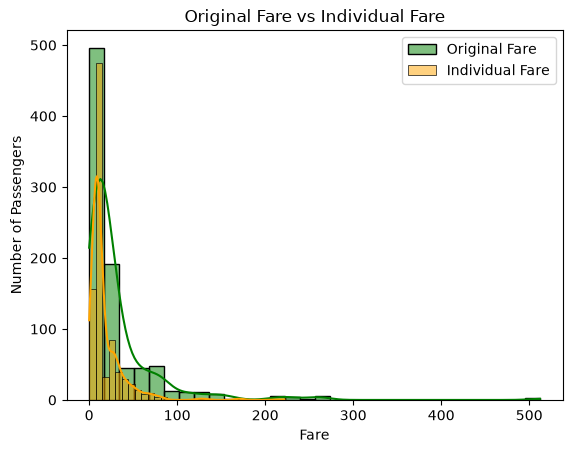

In [59]:
sns.histplot(titanic_data["fare"], kde=True, bins=30, color="green", label="Original Fare")
sns.histplot(titanic_data["IndividualFare"], kde=True, bins=30, color="orange", label="Individual Fare")
plt.title("Original Fare vs Individual Fare")
plt.xlabel("Fare")
plt.ylabel("Number of Passengers")
plt.legend()
plt.show()

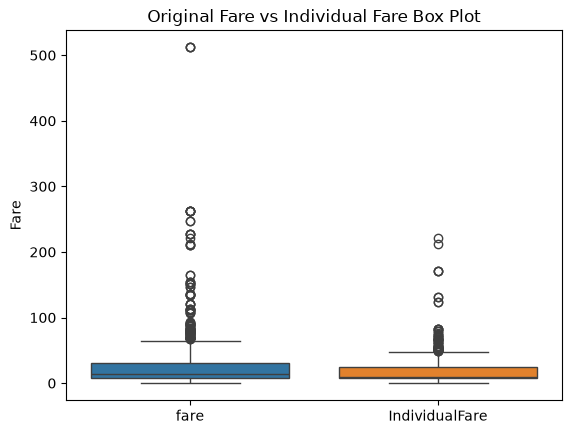

In [60]:
sns.boxplot(data=titanic_data[["fare", "IndividualFare"]])
plt.title("Original Fare vs Individual Fare Box Plot")
plt.ylabel("Fare")
plt.show()

From above plots, it is clear that `IndividualFare` reduces the effect of shared tickets and gives a better view of
what each passenger may have paid individually.

### Univariate Analysis on Categorical Columns

For categorical variables, count plots help us see how many records fall into
each category.

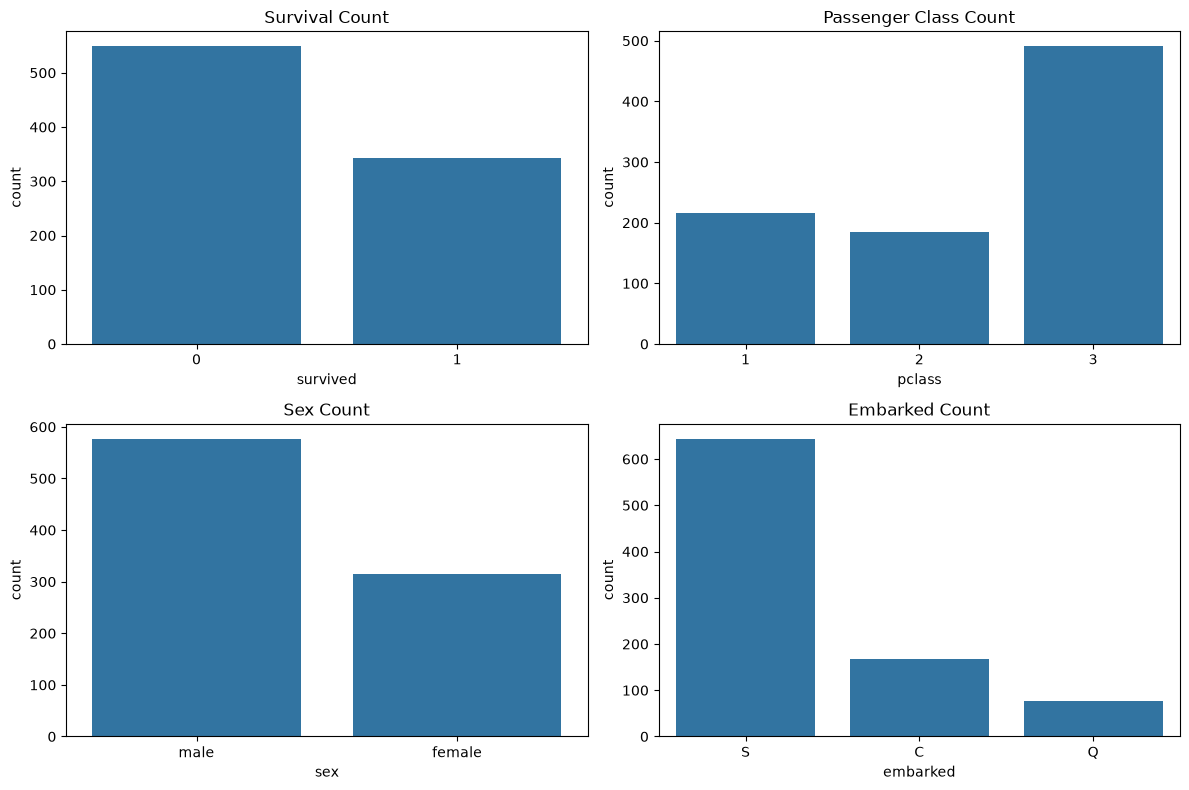

In [61]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

sns.countplot(x="survived", data=titanic_data, ax=axes[0, 0])
axes[0, 0].set_title("Survival Count")

sns.countplot(x="pclass", data=titanic_data, ax=axes[0, 1])
axes[0, 1].set_title("Passenger Class Count")

sns.countplot(x="sex", data=titanic_data, ax=axes[1, 0])
axes[1, 0].set_title("Sex Count")

sns.countplot(x="embarked", data=titanic_data, ax=axes[1, 1])
axes[1, 1].set_title("Embarked Count")

plt.tight_layout()
plt.show()

These plots help us quickly compare the number of passengers in important
categories such as survival status, class, sex, and boarding port.

### Creating FamilySize

The original dataset stores sibling/spouse count in `sibsp` and parent/child
count in `parch`. 

We combine them to create a new column called `FamilySize`.

In [62]:
print("Before creating FamilySize:")
print(titanic_data[["sibsp", "parch"]].head())

titanic_data["FamilySize"] = titanic_data["sibsp"] + titanic_data["parch"] + 1

print("\nAfter creating FamilySize:")
print(titanic_data[["sibsp", "parch", "FamilySize"]].head())

print("\nSummary statistics for FamilySize:")
print(titanic_data["FamilySize"].describe())

Before creating FamilySize:
   sibsp  parch
0      1      0
1      1      0
2      0      0
3      1      0
4      0      0

After creating FamilySize:
   sibsp  parch  FamilySize
0      1      0           2
1      1      0           2
2      0      0           1
3      1      0           2
4      0      0           1

Summary statistics for FamilySize:
count    891.000000
mean       1.904602
std        1.613459
min        1.000000
25%        1.000000
50%        1.000000
75%        2.000000
max       11.000000
Name: FamilySize, dtype: float64


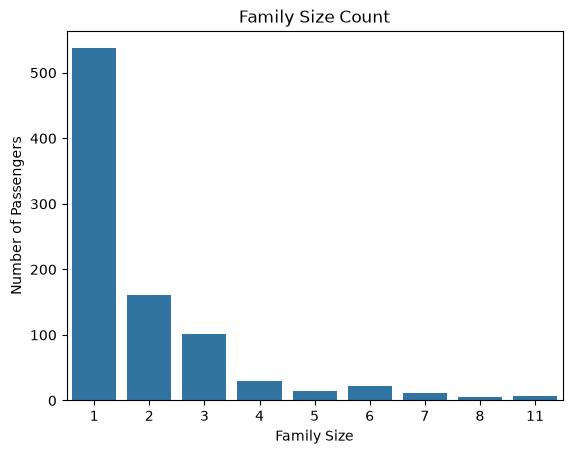

In [63]:
sns.countplot(x="FamilySize", data=titanic_data)
plt.title("Family Size Count")
plt.xlabel("Family Size")
plt.ylabel("Number of Passengers")
plt.show()

`FamilySize` tells us whether a passenger traveled alone or with family. This
may be useful when studying survival patterns.

### Creating Deck from Cabin

The `cabin` column often starts with a deck letter, such as `C` or `B`. Missing
cabin values are marked as `M` for missing.

In [64]:
print("Before creating Deck:")
print(titanic_data[["cabin"]].head(10))

titanic_data["Deck"] = titanic_data["cabin"].str[0].fillna("M")

print("\nAfter creating Deck:")
print(titanic_data[["cabin", "Deck"]].head(10))

Before creating Deck:
  cabin
0   NaN
1   C85
2   NaN
3  C123
4   NaN
5   NaN
6   E46
7   NaN
8   NaN
9   NaN

After creating Deck:
  cabin Deck
0   NaN    M
1   C85    C
2   NaN    M
3  C123    C
4   NaN    M
5   NaN    M
6   E46    E
7   NaN    M
8   NaN    M
9   NaN    M


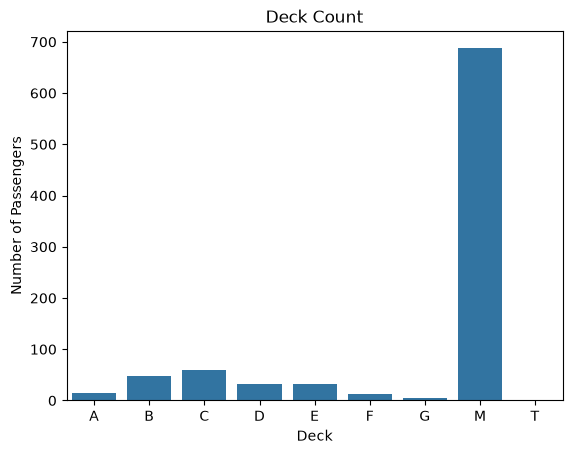

In [65]:
sns.countplot(x="Deck", data=titanic_data, order=sorted(titanic_data["Deck"].unique()))
plt.title("Deck Count")
plt.xlabel("Deck")
plt.ylabel("Number of Passengers")
plt.show()

Many passengers have missing deck information. This reflects that cabin details
were not available for many records.

### Creating Title from Name

The `name` column contains titles such as Mr, Mrs, Miss, and Master.
 
These titles can give useful social information, so we extract them into a new column called `Title`

In [66]:
print("Before creating Title:")
print(titanic_data[["name"]].head())

titanic_data["Title"] = titanic_data["name"].str.extract(r"([A-Za-z]+)\.", expand=False)

print("\nAfter extracting Title:")
print(titanic_data[["name", "Title"]].head())

Before creating Title:
                                                name
0                            Braund, Mr. Owen Harris
1  Cumings, Mrs. John Bradley (Florence Briggs Th...
2                             Heikkinen, Miss. Laina
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)
4                           Allen, Mr. William Henry

After extracting Title:
                                                name Title
0                            Braund, Mr. Owen Harris    Mr
1  Cumings, Mrs. John Bradley (Florence Briggs Th...   Mrs
2                             Heikkinen, Miss. Laina  Miss
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)   Mrs
4                           Allen, Mr. William Henry    Mr


In [67]:
print("\nTitle counts before grouping rare titles:")
print(titanic_data["Title"].value_counts())


Title counts before grouping rare titles:
Title
Mr          517
Miss        182
Mrs         125
Master       40
Dr            7
Rev           6
Major         2
Mlle          2
Col           2
Don           1
Mme           1
Ms            1
Lady          1
Sir           1
Capt          1
Countess      1
Jonkheer      1
Name: count, dtype: int64


From above output, it is clear that `Mr` , `Miss` , `Mrs` and `Master` have majority distribution in the `Title` column.

So, we will combine all other titles into a single category called `Others`

In [68]:
rare_titles = ["Dr", "Rev", "Col", "Major", "Capt", "Don", "Jonkheer", "Sir", "Lady", "Countess"]

titanic_data["Title"] = titanic_data["Title"].replace(rare_titles, "Others")
titanic_data["Title"] = titanic_data["Title"].replace("Ms", "Miss")
titanic_data["Title"] = titanic_data["Title"].replace("Mme", "Mrs")
titanic_data["Title"] = titanic_data["Title"].replace("Mlle", "Miss")

print("Title counts after grouping:")
print(titanic_data["Title"].value_counts())

Title counts after grouping:
Title
Mr        517
Miss      185
Mrs       126
Master     40
Others     23
Name: count, dtype: int64


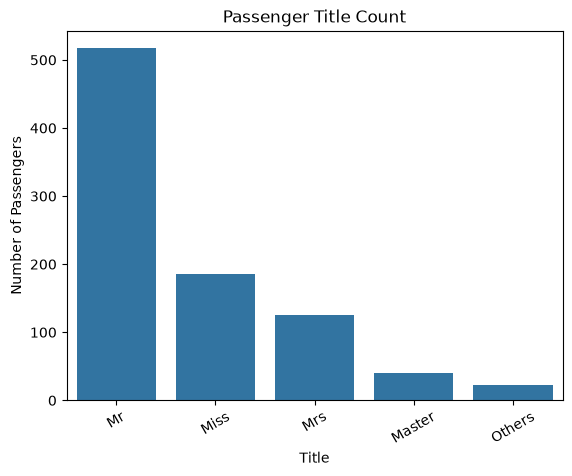

In [69]:
sns.countplot(x="Title", data=titanic_data, order=titanic_data["Title"].value_counts().index)
plt.title("Passenger Title Count")
plt.xlabel("Title")
plt.ylabel("Number of Passengers")
plt.xticks(rotation=30)
plt.show()

Clearly, titles like Mr, Miss, Mrs, and Master are the most frequent. Grouping rare titles
keeps the feature easier to analyze.

## Bivariate Analysis

Bivariate analysis studies the relationship between two variables.

Since the Titanic dataset has a target column named `survived`, we will compare important
features against survival.

### Passenger Class and Survival

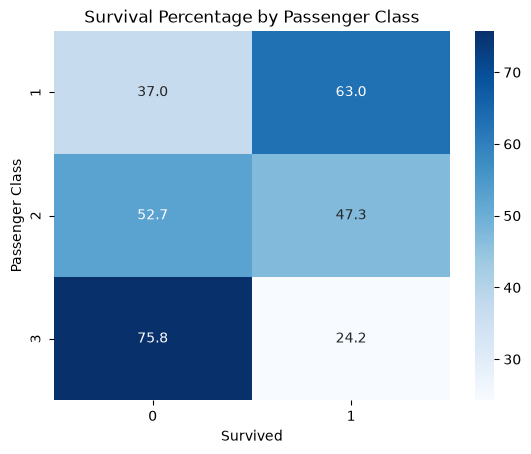

In [70]:
pclass_survived_ct = pd.crosstab(
    titanic_data["pclass"], titanic_data["survived"], normalize="index"
) * 100

sns.heatmap(pclass_survived_ct, annot=True, fmt=".1f", cmap="Blues")
plt.title("Survival Percentage by Passenger Class")
plt.xlabel("Survived")
plt.ylabel("Passenger Class")
plt.show()

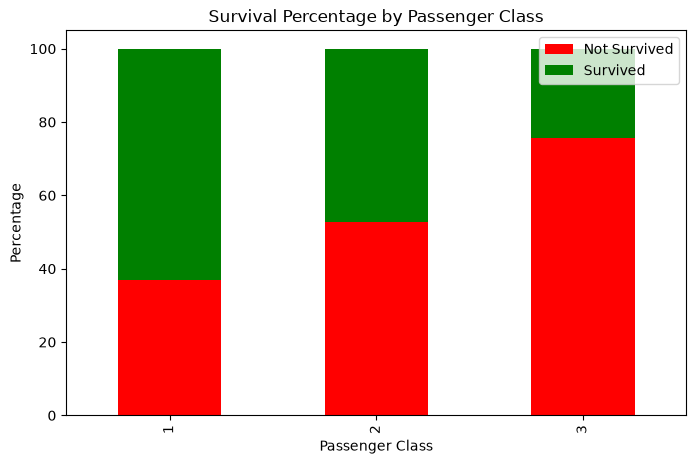

In [71]:
pclass_survived_ct.plot(kind="bar", stacked=True, figsize=(8, 5), color=["red", "green"])
plt.title("Survival Percentage by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Percentage")
plt.legend(["Not Survived", "Survived"])
plt.show()

Passenger class shows a clear survival pattern. First-class passengers had a
higher survival percentage than lower-class passengers.

### Sex and Survival

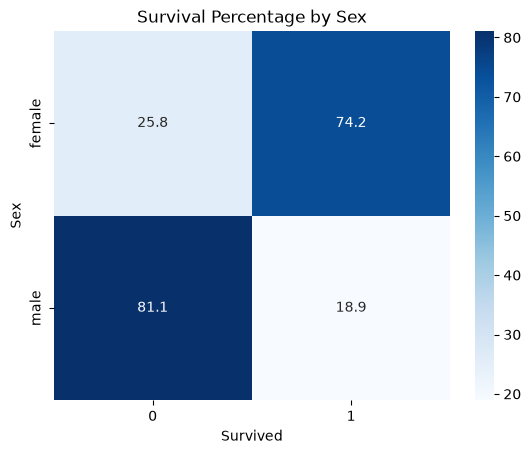

In [72]:
sex_survived_ct = pd.crosstab(
    titanic_data["sex"], titanic_data["survived"], normalize="index"
) * 100

sns.heatmap(sex_survived_ct, annot=True, fmt=".1f", cmap="Blues")
plt.title("Survival Percentage by Sex")
plt.xlabel("Survived")
plt.ylabel("Sex")
plt.show()

Survival percentages differ strongly by sex, which makes `sex` an important
feature to consider in later modeling.

### Age and Survival

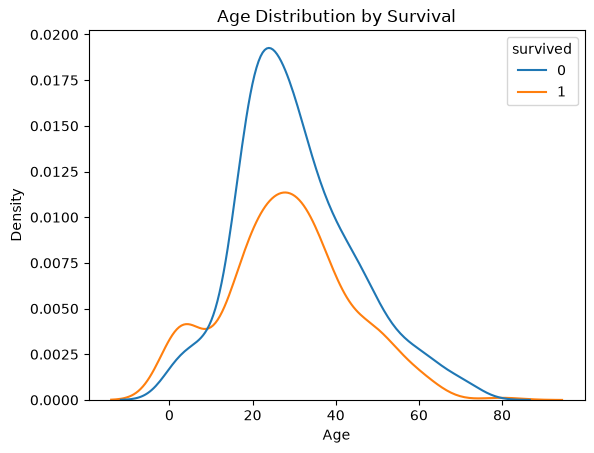

Age summary grouped by survival:
          count       mean        std   min   25%   50%   75%   max
survived                                                           
0         424.0  30.626179  14.172110  1.00  21.0  28.0  39.0  74.0
1         290.0  28.343690  14.950952  0.42  19.0  28.0  36.0  80.0


In [73]:
sns.kdeplot(data=titanic_data, x="age", hue="survived")
plt.title("Age Distribution by Survival")
plt.xlabel("Age")
plt.ylabel("Density")
plt.show()

print("Age summary grouped by survival:")
print(titanic_data.groupby("survived")["age"].describe())

Comparing age by survival helps us see whether different age groups had
different survival patterns.

### IndividualFare and Survival

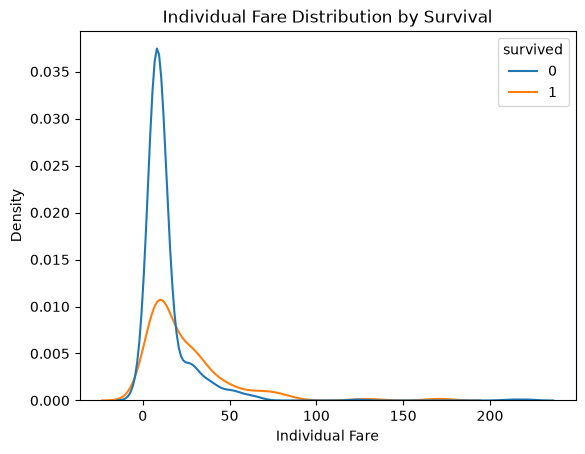

Individual fare summary grouped by survival:
          count       mean        std  min    25%    50%   75%       max
survived                                                                
0         549.0  13.523869  17.137983  0.0  7.725   8.05  13.0  221.7792
1         342.0  24.635628  25.034579  0.0  7.950  13.00  30.0  170.7764


In [74]:
sns.kdeplot(data=titanic_data, x="IndividualFare", hue="survived")
plt.title("Individual Fare Distribution by Survival")
plt.xlabel("Individual Fare")
plt.ylabel("Density")
plt.show()

print("Individual fare summary grouped by survival:")
print(titanic_data.groupby("survived")["IndividualFare"].describe())

Fare is connected to passenger class and socio-economic status, so it can also
show useful survival patterns.

### Embarked and Survival

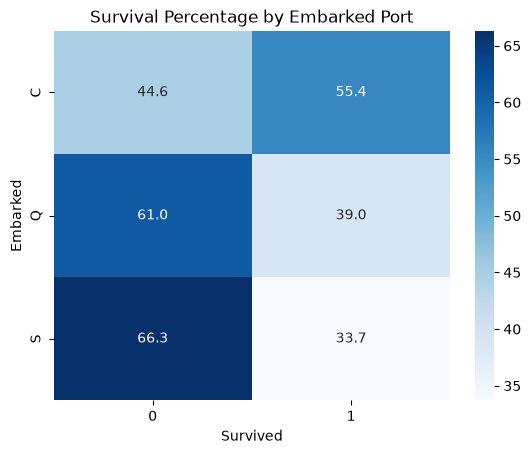

In [75]:
embarked_survived_ct = pd.crosstab(
    titanic_data["embarked"], titanic_data["survived"], normalize="index"
) * 100

sns.heatmap(embarked_survived_ct, annot=True, fmt=".1f", cmap="Blues")
plt.title("Survival Percentage by Embarked Port")
plt.xlabel("Survived")
plt.ylabel("Embarked")
plt.show()

This comparison checks whether survival rates differed by boarding port.

### Engineered Features and Survival

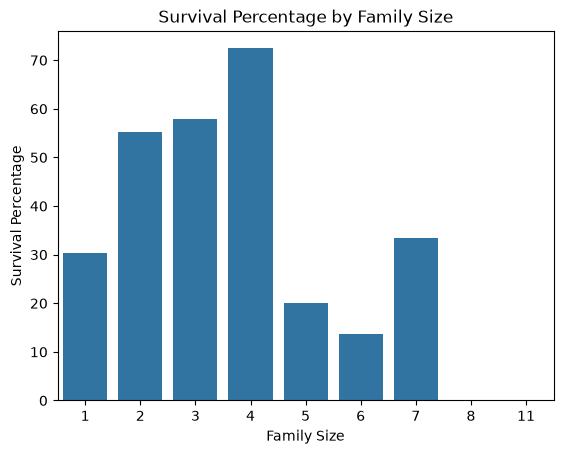

In [76]:
family_survival = titanic_data.groupby("FamilySize")["survived"].mean() * 100
sns.barplot(x=family_survival.index, y=family_survival.values)
plt.title("Survival Percentage by Family Size")
plt.xlabel("Family Size")
plt.ylabel("Survival Percentage")
plt.show()

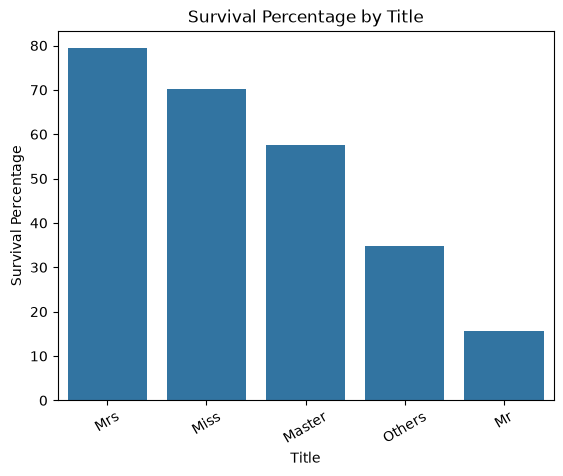

In [77]:
title_survival = titanic_data.groupby("Title")["survived"].mean().sort_values(ascending=False) * 100
sns.barplot(x=title_survival.index, y=title_survival.values)
plt.title("Survival Percentage by Title")
plt.xlabel("Title")
plt.ylabel("Survival Percentage")
plt.xticks(rotation=30)
plt.show()

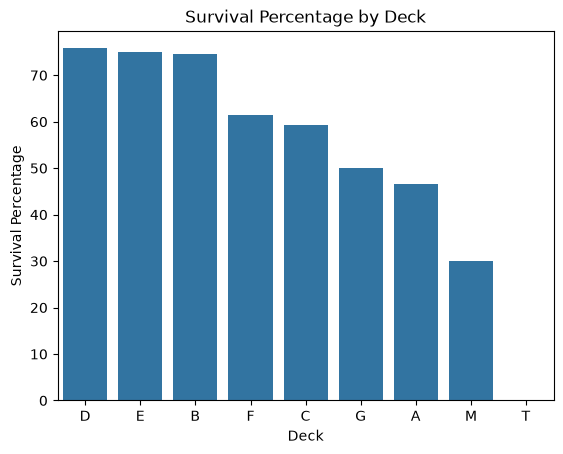

In [78]:
deck_survival = titanic_data.groupby("Deck")["survived"].mean().sort_values(ascending=False) * 100
sns.barplot(x=deck_survival.index, y=deck_survival.values)
plt.title("Survival Percentage by Deck")
plt.xlabel("Deck")
plt.ylabel("Survival Percentage")
plt.show()

The engineered columns `FamilySize`, `Title`, and `Deck` help us discover
patterns that were not directly visible in the raw columns.

## Multivariate Analysis

Multivariate analysis studies three or more variables together. Here we examine
how passenger class and sex together relate to survival.

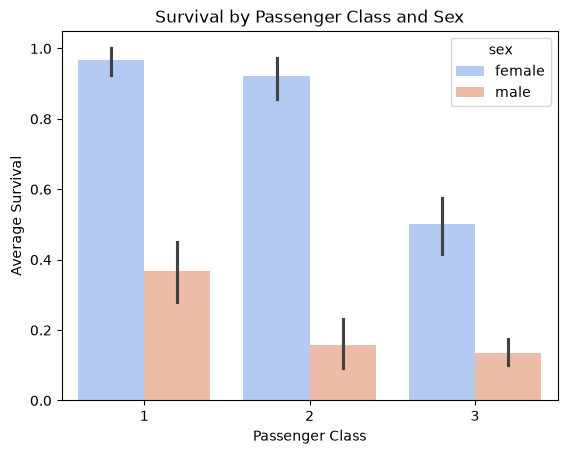

In [79]:
sns.barplot(data=titanic_data, x="pclass", y="survived", hue="sex", palette="coolwarm")
plt.title("Survival by Passenger Class and Sex")
plt.xlabel("Passenger Class")
plt.ylabel("Average Survival")
plt.show()

This plot shows that survival is not explained by one feature alone. Class and
sex together reveal a stronger pattern.

### Pair Plot

A pair plot gives a quick visual summary of relationships among numerical
variables.

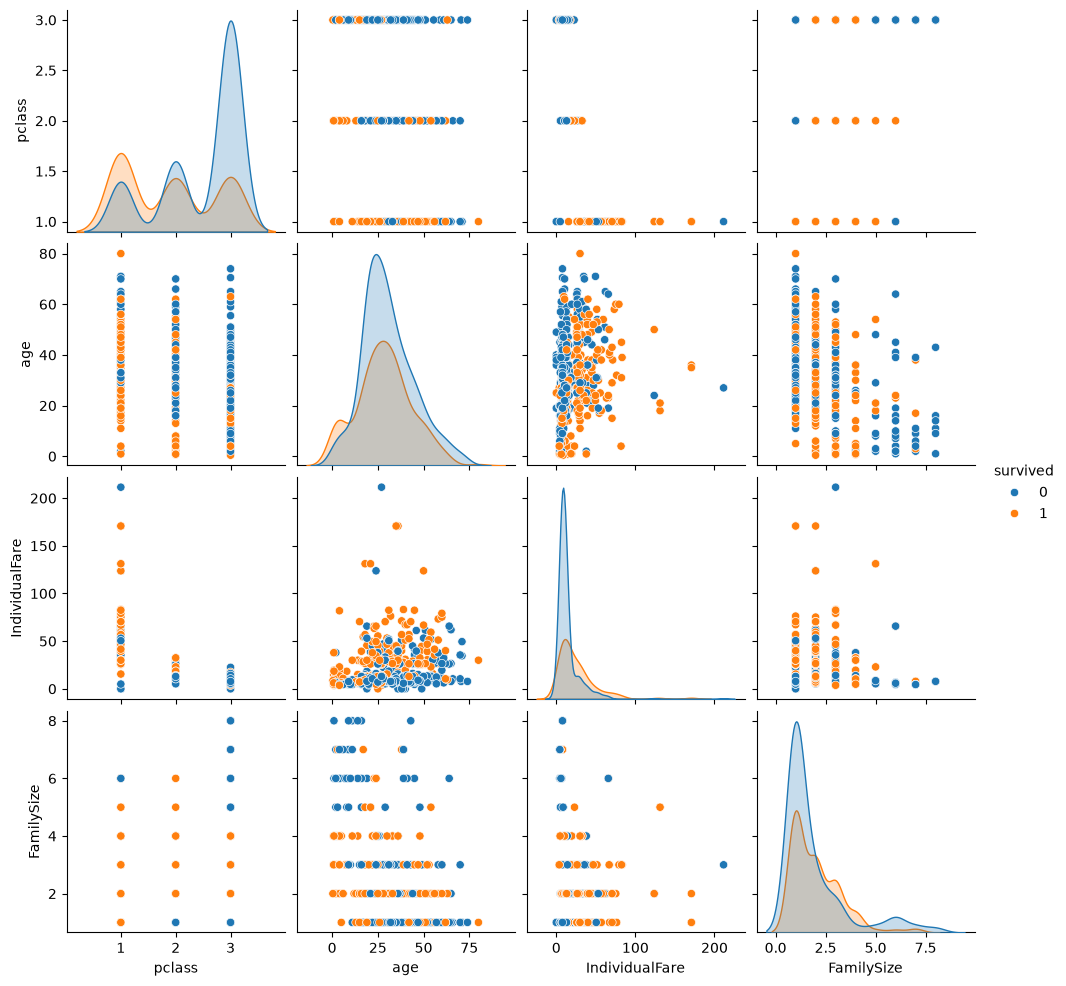

In [80]:
pairplot_columns = ["survived", "pclass", "age", "IndividualFare", "FamilySize"]
sns.pairplot(titanic_data[pairplot_columns].dropna(), hue="survived")
plt.show()

The pair plot helps us scan several relationships at once. It is useful for
spotting clusters, separation, and possible relationships between numerical
variables.

## Correlation Analysis

Correlation analysis works on numerical values. To include categorical columns,
we first encode them.

In [81]:
encoded_data = titanic_data.copy()

print("Before encoding categorical columns:")
print(encoded_data[["sex", "embarked", "Title", "Deck"]].head())

# Label Encoding is used for sex because it has two categories.
label_encoder = LabelEncoder()
encoded_data["sex"] = label_encoder.fit_transform(encoded_data["sex"].astype(str))

# One-Hot Encoding is used for unordered categorical columns.
encoded_data = pd.get_dummies(encoded_data, columns=["embarked", "Title", "Deck"], dummy_na=True)

print("\nAfter encoding selected categorical columns:")
encoded_preview_cols = [col for col in encoded_data.columns if col == "sex" or col.startswith(("embarked_", "Title_", "Deck_"))]
print(encoded_data[encoded_preview_cols].head())

# Keep only numeric and boolean columns for correlation.
encoded_data = encoded_data.select_dtypes(include=["float64", "int64", "bool"])

print("\nEncoded data columns used for correlation:")
print(encoded_data.columns.tolist())

Before encoding categorical columns:
      sex embarked Title Deck
0    male        S    Mr    M
1  female        C   Mrs    C
2  female        S  Miss    M
3  female        S   Mrs    C
4    male        S    Mr    M

After encoding selected categorical columns:
   sex  embarked_C  embarked_Q  embarked_S  embarked_nan  Title_Master  \
0    1       False       False        True         False         False   
1    0        True       False       False         False         False   
2    0       False       False        True         False         False   
3    0       False       False        True         False         False   
4    1       False       False        True         False         False   

   Title_Miss  Title_Mr  Title_Mrs  Title_Others  ...  Deck_A  Deck_B  Deck_C  \
0       False      True      False         False  ...   False   False   False   
1       False     False       True         False  ...   False   False    True   
2        True     False      False         False 

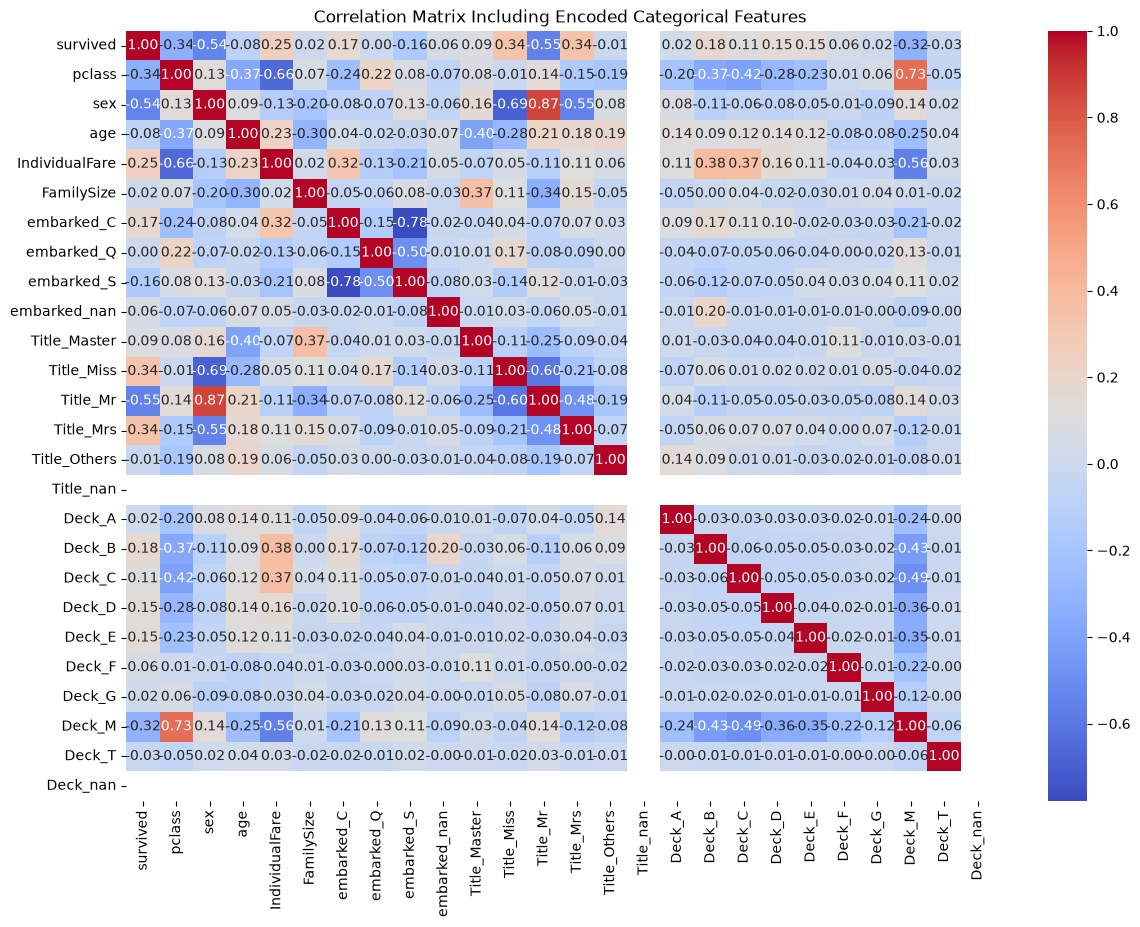

In [82]:
correlation_matrix = encoded_data.drop(
    columns=["sibsp", "parch", "GroupSize", "fare"], errors="ignore"
).corr()

plt.figure(figsize=(14, 10))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Correlation Matrix Including Encoded Categorical Features")
plt.show()

The correlation heatmap helps us identify which numerical and encoded
categorical features are most related to survival. These insights can guide
feature selection in the modeling stage.

## Chapter Recap

In this chapter we used the Titanic dataset to practice Exploratory Data
Analysis.

- We loaded and inspected the dataset.
- We checked missing values and duplicate rows.
- We separated numerical and categorical variables.
- We performed univariate analysis using summaries, histograms, count plots, and
  box plots.
- We engineered useful features such as `IndividualFare`, `FamilySize`, `Deck`,
  and `Title`.
- We performed bivariate analysis by comparing important features with survival.
- We performed multivariate analysis using class, sex, and survival together.
- We used a pair plot and a correlation heatmap to study multiple relationships.

EDA helps us understand the data before modeling. It gives us the clues needed
to clean better, engineer better features, and choose better modeling strategies.

